### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [9]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

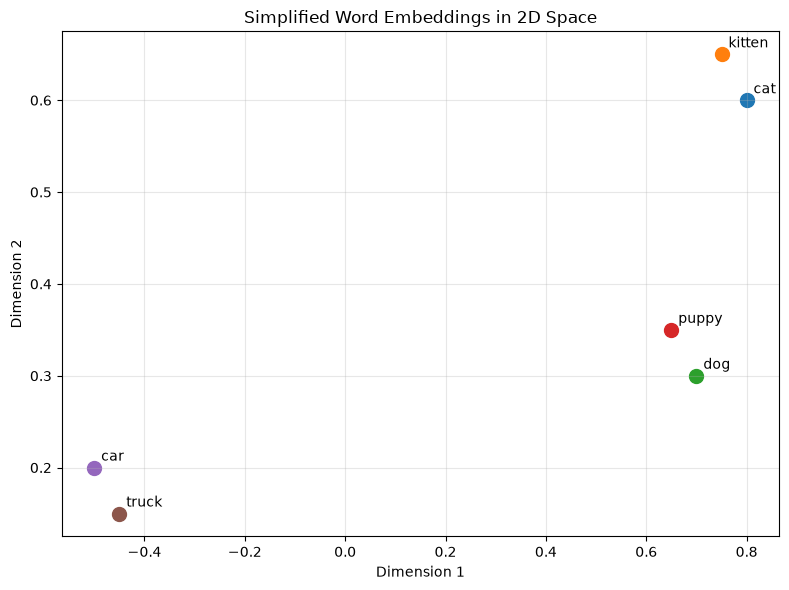

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [11]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)



In [ ]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

#cosine similarity requires both vectors to have the exact same number of dimensions
#Mathematically, cosine similarity measures the angle between two vectors at a time.
#Cosine similarity and self-attention are two completely different things.
#Self-attention happens inside the Transformer.
#Cosine similarity usually happens after you have an embedding.

0.9966186334192181


In [22]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

### Creating Your First Embeddings

In [ ]:
### Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings




c:\Users\nihar\MLRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nihar\MLRAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nihar\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate devel

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [15]:
## create your first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)


Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.01816326379776001, -0.09955169260501862, 0.013816027902066708, -0.00812597293406725, 0.01415228471159935, 0.0640648677945137, -0.006253377068787813, -0.003017888404428959, 0.025287209078669548, -0.02019863948225975, 0.02432972751557827, 0.07435064017772675, 0.05117722973227501, 0.02203851193189621, -0.05830617621541023, 0.01526821218430996, 0.023584362119436264, 0.09455390274524689, -0.06508845090866089, 0.013296646066009998, -0.020497558638453484, -0.05690857768058777, 0.03030332177877426, -0.08365609496831894, 0.026596298441290855, -0.015231452882289886, -0.04361540079116821, 0.05398401618003845, 0.09025716781616211, -0.08893883973360062, 0.03964461758732796, -0.008835024200379848, -0.03034374490380287, 0.07425564527511597, -0.0540991947054863, 0.11107997596263885, 0.036899879574775696, -0.008959847502410412, -0.06140241026878357, -0.0031433829572051764, 0.021958177909255028, 0.04220819100737572, -0.0289378669112

In [23]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])   # see here both sentence gets same vectors if 2 are not related or something different then different vectors

[0.1304018348455429, -0.01187008898705244, -0.02811703085899353, 0.05123864859342575, -0.055974479764699936, 0.03019154630601406, 0.030161265283823013, 0.02469840832054615, -0.01837059296667576, 0.05876680463552475, -0.024953173473477364, 0.0601542629301548, 0.039831776171922684, 0.033230509608983994, -0.06131136044859886, -0.04937314614653587, -0.05486352741718292, -0.040076058357954025, 0.056429117918014526, 0.03915657475590706, -0.03473714366555214, -0.013247663155198097, 0.031966231763362885, -0.06349924206733704, -0.06017862260341644, 0.07823451608419418, -0.028303898870944977, -0.047442857176065445, 0.040359288454055786, -0.006630914285778999, -0.0667409673333168, -0.004191394429653883, -0.025311686098575592, 0.05334167927503586, 0.01742812804877758, -0.09792362153530121, 0.006061307154595852, -0.06524164229631424, 0.045572590082883835, 0.02364179864525795, 0.0765848234295845, -0.01026437059044838, -0.004076848272234201, -0.062322795391082764, 0.03370528295636177, 0.0186610929667

In [17]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications



In [20]:
#Below is concept of mean Pooling while combines all token vectors in single vector

The biggest advantage of mean pooling is that it converts many token vectors of variable length into one fixed-size vector that represents the whole sentence. but why this

Because similarity search needs comparable vectors.

That's the core reason.

Imagine you have these two sentences:

"I like cats"

"I really like cats because they are friendly animals"

After tokenization, they have different numbers of tokens.

A Transformer produces a vector for each token.

Let's simplify the embedding dimension to 4:

"I like cats"


I       → [0.2, 0.5, 0.1, 0.7]
like    → [0.8, 0.2, 0.6, 0.3]
cats    → [0.4, 0.9, 0.3, 0.5]


Shape = 3 × 4

The second sentence might produce:

I        → [....]
really   → [....]
like     → [....]
cats     → [....]
because  → [....]
they     → [....]
are      → [....]
friendly → [....]
animals  → [....]


Shape = 9 × 4

Now here's the problem:

How do you compare them?

You want to ask:

"Are these two sentences talking about similar things?"

But you have:

Sentence A → 3 × 4
Sentence B → 9 × 4

They're different shapes.

You can't simply calculate a normal cosine similarity between:

3 × 4

and:

9 × 4

because cosine similarity expects two vectors of the same dimensionality.

Mean pooling solves this

Take all the token vectors and average them column by column.

Sentence A:

3 × 4

becomes:

1 × 4

Sentence B:

9 × 4

also becomes:

1 × 4

Now:

Sentence A → [0.47, 0.53, 0.33, 0.50]
Sentence B → [0.51, 0.49, 0.36, 0.48]

Now you can calculate:

Cosine Similarity
       ↓
A ↔ B
Why is this particularly important for RAG?

Imagine your PDF has chunks:

Chunk 1 → 80 tokens
Chunk 2 → 150 tokens
Chunk 3 → 300 tokens
Chunk 4 → 120 tokens

And your question:

"What is self-attention?"

Maybe it's 5 tokens.

The Transformer gives:

Question → 5 × 384
Chunk 1  → 80 × 384
Chunk 2  → 150 × 384
Chunk 3  → 300 × 384
Chunk 4  → 120 × 384

You want to compare:

Question ↔ Chunk 1
Question ↔ Chunk 2
Question ↔ Chunk 3
Question ↔ Chunk 4

So we need:

Question → 384
Chunk 1  → 384
Chunk 2  → 384
Chunk 3  → 384
Chunk 4  → 384

Now vector similarity is possible.

                Question
                  ↓
              [384-D]
             ↙   ↓   ↘
        [384-D] [384-D] [384-D]
         Chunk    Chunk    Chunk
           1        2        3

That's the practical reason for mean pooling.

But there's an even deeper reason

The Transformer has already made the token representations contextual.

For example:

"I deposited money at the bank."

The representation of bank has information influenced by:

I → deposited → money → at → the → bank

So you're not simply averaging dictionary definitions of words.

You're averaging contextualized representations:

Contextual token 1 ──┐
Contextual token 2 ──┤
Contextual token 3 ──┤
Contextual token 4 ──┼──→ Mean → sentence meaning
Contextual token 5 ──┤
Contextual token 6 ──┘

So the chain is:

Variable-length text → variable number of contextual token vectors → mean pooling → fixed 384-D representation → compare texts using cosine similarity.

That's why the fixed-size vector is so valuable.

In [ ]:
from IPython.display import HTML, display

html = """
<!DOCTYPE html>
<html>
<head>
<style>
body {
    font-family: Arial, sans-serif;
    padding: 20px;
}

.step {
    display: inline-block;
    padding: 10px 15px;
    margin: 5px;
    border: 1px solid #aaa;
    border-radius: 8px;
    cursor: pointer;
}

.step:hover {
    background: #eee;
}

.box {
    border: 1px solid #aaa;
    border-radius: 10px;
    padding: 20px;
    margin-top: 20px;
}

.token {
    display: inline-block;
    padding: 10px;
    margin: 5px;
    border: 1px solid #777;
    border-radius: 6px;
}

.vector {
    font-family: monospace;
    word-break: break-all;
}
</style>
</head>

<body>

<h2>MiniLM Embedding Visualizer</h2>

<input id="text"
       value="I love learning about embeddings"
       style="width:400px;padding:10px;">

<button onclick="visualize()">Visualize</button>

<div id="steps"></div>

<div class="box">
    <h3 id="title">Text</h3>
    <p id="description">
        Start with the complete sentence.
    </p>

    <div id="visual"></div>
</div>

<script>

let currentStep = 0;

const steps = [
    "Text",
    "Tokenize",
    "Initial Representations",
    "Transformer Layers",
    "Contextualized Tokens",
    "Mean Pooling",
    "384-D Embedding"
];

function tokenize(text) {

    let words = text.trim().split(/\\s+/);

    return ["[CLS]", ...words, "[SEP]"];
}

function showStep(step) {

    currentStep = step;

    const text =
        document.getElementById("text").value;

    const tokens = tokenize(text);

    document.getElementById("title").innerText =
        (step + 1) + ". " + steps[step];

    let visual =
        document.getElementById("visual");

    if (step === 0) {

        visual.innerHTML = `
            <div class="box">
                ${text}
            </div>
        `;

    }

    else if (step === 1) {

        visual.innerHTML = `
            <h4>Tokens</h4>
            ${tokens.map(t =>
                `<span class="token">${t}</span>`
            ).join("")}

            <p>
                ${tokens.length} tokens
            </p>
        `;

    }

    else if (step === 2) {

        visual.innerHTML = `
            <h4>Each token gets a vector</h4>

            ${tokens.map(t => `
                <div class="box">
                    <b>${t}</b>
                    →
                    [384 numbers]
                </div>
            `).join("")}
        `;

    }

    else if (step === 3) {

        visual.innerHTML = `
            <h4>MiniLM has 6 Transformer layers</h4>

            ${[1,2,3,4,5,6].map(i => `
                <div class="box">
                    Transformer Layer ${i}
                    <br>
                    ↓ Self-Attention
                    <br>
                    ↓ Feed Forward
                </div>
            `).join("")}
        `;

    }

    else if (step === 4) {

        visual.innerHTML = `
            <h4>Contextualized representations</h4>

            ${tokens.map(t => `
                <div class="box">
                    ${t}
                    →
                    contextual 384-D vector
                </div>
            `).join("")}
        `;

    }

    else if (step === 5) {

        visual.innerHTML = `
            <h4>Mean Pooling</h4>

            <div class="box">
                ${tokens.join(" + ")}
            </div>

            <h3>↓</h3>

            <div class="box">
                Mean of token representations
            </div>

            <h3>↓</h3>

            <div class="box">
                One 384-dimensional vector
            </div>
        `;

    }

    else if (step === 6) {

        let numbers = [];

        for(let i = 0; i < 384; i++) {

            numbers.push(
                (Math.random() * 2 - 1).toFixed(3)
            );

        }

        visual.innerHTML = `
            <h4>Final Sentence Embedding</h4>

            <div class="box vector">
                [${numbers.join(", ")}]
            </div>

            <h3>
                Dimension = 384
            </h3>
        `;
    }
}

function visualize() {

    const stepsDiv =
        document.getElementById("steps");

    stepsDiv.innerHTML =
        steps.map((step, i) =>
            `<span class="step"
                   onclick="showStep(${i})">
                ${i + 1}. ${step}
             </span>`
        ).join("");

    showStep(0);
}

visualize();

</script>

</body>
</html>
"""

display(HTML(html))


what is np.linalg.norm(vec1) ?  magnitude/length of your embedding vector.

We need np.linalg.norm(vec1) to normalize the vector's length so cosine similarity measures how similarly the vectors are pointing. Because cosine similarity wants to compare the direction of two vectors, not how large they are.

That's the whole reason we need np.linalg.norm().

Imagine two vectors
A = [3, 4]
B = [6, 8]

Notice:

B = 2 × A

So they point in exactly the same direction.

       B
      ↗
     /
    /
   ↗ A

We would want their cosine similarity to be 1 (100% similar).

But look at the dot product:

A⋅B=3(6)+4(8)=50

That's not 1.

The problem is that the dot product is affected by vector length.

Normalize the length

The lengths are:

∥A∥=5

and

∥B∥=10

So cosine similarity does:

∥A∥∥B∥
A⋅B
	​

=
5×10
50
	​

=1

Now we get what we wanted:

A and B point in exactly the same direction → similarity = 1.

Why does this matter for embeddings?

Imagine your embedding model produces:

"I like pizza"
→ vector A

and:

"I really like pizza"
→ vector B

Their vector lengths might be different.

You generally don't want:

"This vector is bigger, therefore this sentence is more similar."

You want to compare their direction in embedding space.

So cosine similarity effectively says:

Vector A ── normalize length ──┐
                               ├── compare direction
Vector B ── normalize length ──┘
The easiest way to remember

Dot product:

"How much do these vectors point together, considering their size?"

Norm:

"How long is this vector?"

Cosine similarity:

"How similar are their directions, regardless of their length?"

That's why your formula needs:

np.linalg.norm(vec1)
np.linalg.norm(vec2)

to remove the effect of magnitude.

The magnitude/length is a single number that tells you how large the vector is overall.

For a vector:

[3, 4]

its magnitude is:

3
2
+4
2
	​

=5

So the vector:

[3, 4]

has:

2 dimensions → because it has 2 numbers
magnitude = 5 → its overall length

For a 1,526-dimensional embedding:

[x₁, x₂, x₃, ..., x₁₅₂₆]

the magnitude is:

x
1
2
	​

+x
2
2
	​

+⋯+x
1526
2
	​

	​


That gives one number representing the overall length of the vector in 1,526-dimensional space.

Why do we care about this length?

Because a vector has two properties:

Vector
├── Direction → which way it points
└── Magnitude → how long it is

Cosine similarity wants the direction, not the length.

That's why we calculate the magnitude with:

np.linalg.norm(vec1)

and use it to remove the effect of vector length from the cosine-similarity calculation.

-----------------------------------------------------------------------------------------------------------

magnitude = 5 → its overall length

so what is this overaal length

"Overall length" means the distance from the starting point (origin) to the endpoint of the vector.

For:

vec = [3, 4]

you can visualize it as an arrow starting at (0,0) and ending at (3,4):

(0,4) |             ● (3,4)
      |           /
      |         /
      |       /   ← vector
      |     /
(0,0) ●──────────────
          3

The arrow has a length of 5.

That's because:

length=
3
2
+4
2
	​

=5

So when we say:

Magnitude = overall length

we simply mean:

How far the vector's endpoint is from the origin.

For a 1,526-dimensional embedding, you can't draw the arrow, but mathematically it has the same concept: the distance from the origin in 1,526-dimensional space.